# Analyse Exploratoire des Données (EDA)
## Projet Churn Prediction — EFREI M1 Data Engineering

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

df = pd.read_csv('../data/raw/customer_churn.csv')
print(df.shape)
df.head()

(10000, 32)


,customer_id,gender,age,country,city,customer_segment,tenure_months,signup_channel,contract_type,monthly_logins,weekly_active_days,avg_session_time,features_used,usage_growth_rate,last_login_days_ago,monthly_fee,total_revenue,payment_method,payment_failures,discount_applied,price_increase_last_3m,support_tickets,avg_resolution_time,complaint_type,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,survey_response,referral_count,churn
0,CUST_00001,Male,68,Bangladesh,London,SME,22,Web,Monthly,26,7,11.762372,5,0.06,7,30,660,PayPal,1,Yes,No,4,13.354360,Service,4.0,0,0.71,0.40,27,Satisfied,1,0
1,CUST_00002,Female,57,Canada,Sydney,Individual,9,Mobile,Monthly,7,5,26.846390,1,-0.28,2,30,270,Card,1,No,Yes,1,25.140088,Billing,2.0,0,0.78,0.33,-19,Neutral,2,1
2,CUST_00003,Male,24,Germany,New York,SME,58,Web,Yearly,19,5,23.380065,6,0.13,23,20,1160,Card,2,No,No,1,27.572928,Service,3.0,0,0.35,0.49,80,Neutral,1,0
3,CUST_00004,Male,49,Australia,Dhaka,Individual,19,Mobile,Yearly,34,7,24.243136,2,-0.17,24,30,570,Bank Transfer,0,Yes,No,3,26.420822,Technical,5.0,1,0.83,0.15,100,Neutral,0,0
4,CUST_00005,Male,65,Bangladesh,Delhi,Individual,52,Web,Monthly,20,6,18.872323,2,-0.16,2,50,2600,PayPal,0,No,No,0,26.674579,Technical,4.0,0,0.65,0.44,21,Unsatisfied,1,0


## 1. Aperçu général

In [2]:
print('Types de données :')
print(df.dtypes)
print('\nValeurs manquantes :')
print(df.isnull().sum())
print('\nStatistiques descriptives :')
df.describe()

Types de données :
customer_id                   str
gender                        str
age                         int64
country                       str
city                          str
customer_segment              str
tenure_months               int64
signup_channel                str
contract_type                 str
monthly_logins              int64
weekly_active_days          int64
avg_session_time          float64
features_used               int64
usage_growth_rate         float64
last_login_days_ago         int64
monthly_fee                 int64
total_revenue               int64
payment_method                str
payment_failures            int64
discount_applied              str
price_increase_last_3m        str
support_tickets             int64
avg_resolution_time       float64
complaint_type                str
csat_score                float64
escalations                 int64
email_open_rate           float64
marketing_click_rate      float64
nps_score                   i

,age,tenure_months,monthly_logins,weekly_active_days,avg_session_time,features_used,usage_growth_rate,last_login_days_ago,monthly_fee,total_revenue,payment_failures,support_tickets,avg_resolution_time,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,referral_count,churn
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.0000,10000.000000
mean,45.906100,30.155700,19.672000,3.479400,15.187890,4.990800,0.019423,9.505200,34.930000,1057.018000,0.501000,1.206600,23.953210,3.486700,0.294100,0.499610,0.253575,19.110500,0.9922,0.102100
std,16.420416,17.099517,9.838003,2.302283,6.830774,2.211607,0.149567,9.799417,23.785115,1020.148233,0.711934,1.104554,9.956999,0.978631,0.543171,0.231601,0.140532,38.936619,0.9939,0.302795
min,18.000000,1.000000,0.000000,0.000000,1.000000,1.000000,-0.580000,0.000000,10.000000,10.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.100000,0.010000,-100.000000,0.0000,0.000000
25%,32.000000,16.000000,13.000000,1.000000,10.391645,3.000000,-0.080000,2.000000,20.000000,340.000000,0.000000,0.000000,17.082041,3.000000,0.000000,0.300000,0.130000,-7.000000,0.0000,0.000000
50%,46.000000,30.000000,20.000000,3.000000,15.161659,5.000000,0.020000,6.000000,30.000000,720.000000,0.000000,1.000000,23.950444,4.000000,0.000000,0.500000,0.250000,19.000000,1.0000,0.000000
75%,60.000000,45.000000,26.000000,5.000000,19.882034,6.000000,0.120000,13.000000,50.000000,1440.000000,1.000000,2.000000,30.758480,4.000000,1.000000,0.700000,0.380000,46.000000,2.0000,0.000000
max,74.000000,59.000000,54.000000,7.000000,41.996411,15.000000,0.540000,80.000000,100.000000,5900.000000,5.000000,7.000000,61.821878,5.000000,4.000000,0.900000,0.500000,100.000000,7.0000,1.000000


## 2. Distribution de la variable cible (churn)

Churn rate : 10.2%
churn
0    8979
1    1021
Name: count, dtype: int64


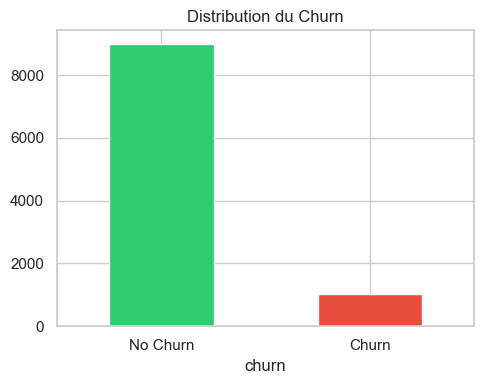

In [3]:
churn_counts = df['churn'].value_counts()
print(f'Churn rate : {df["churn"].mean():.1%}')
print(churn_counts)

fig, ax = plt.subplots(figsize=(5, 4))
churn_counts.plot.bar(ax=ax, color=['#2ecc71', '#e74c3c'])
ax.set_xticklabels(['No Churn', 'Churn'], rotation=0)
ax.set_title('Distribution du Churn')
plt.tight_layout()
plt.show()

## 3. Distributions des variables numériques

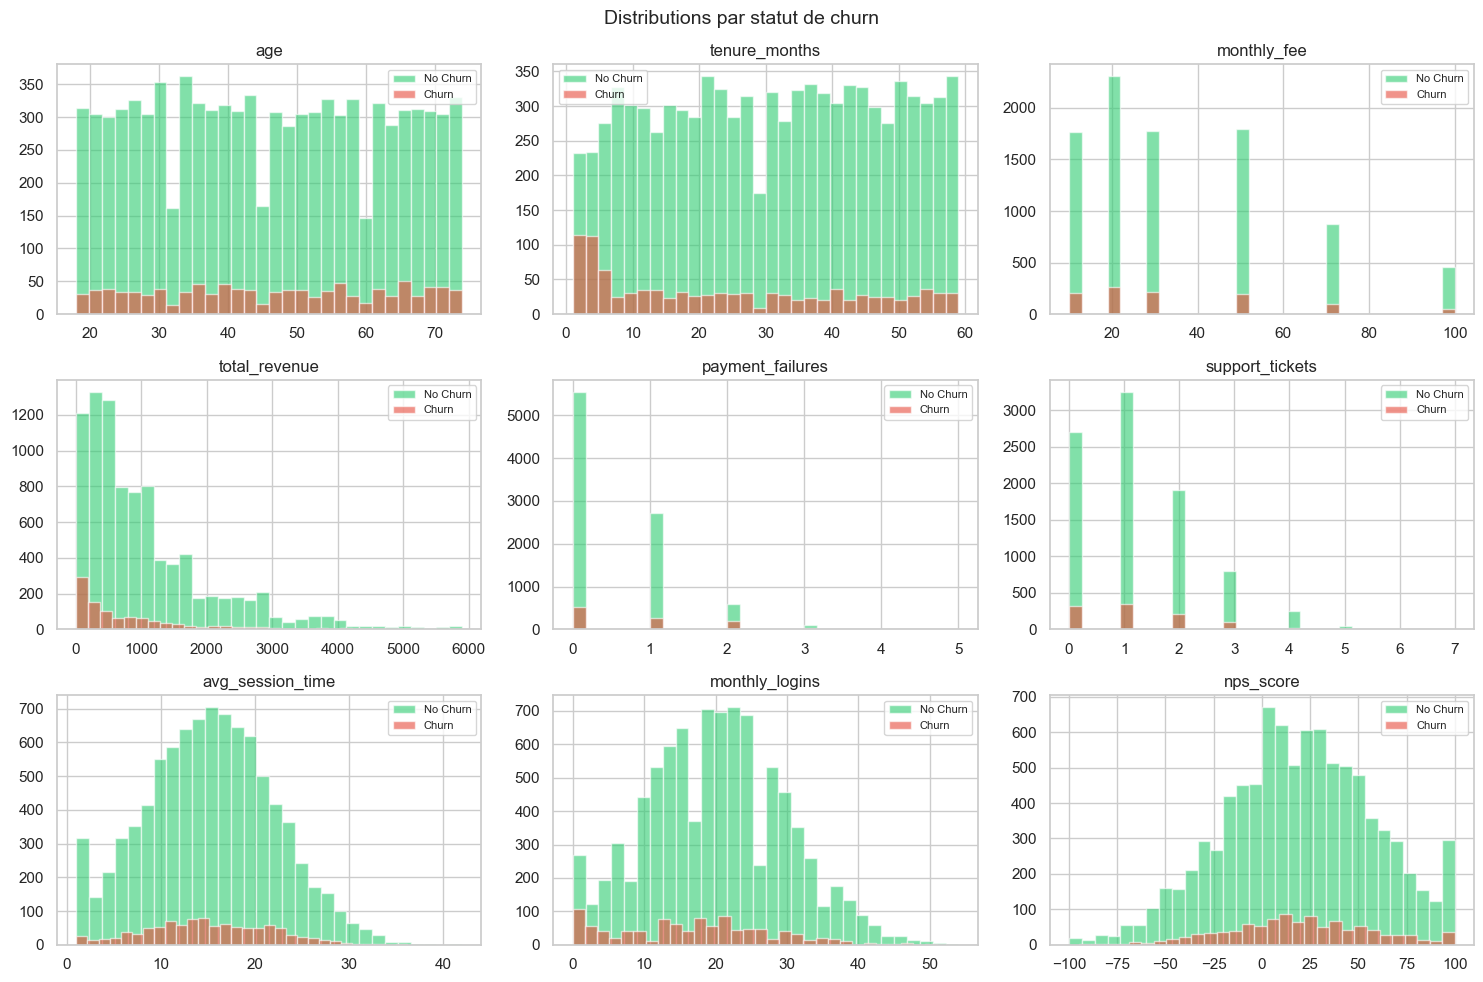

In [4]:
numeric_cols = ['age', 'tenure_months', 'monthly_fee', 'total_revenue',
                'payment_failures', 'support_tickets', 'avg_session_time',
                'monthly_logins', 'nps_score']

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, col in zip(axes.flatten(), numeric_cols):
    df[df['churn'] == 0][col].hist(ax=ax, alpha=0.6, color='#2ecc71', label='No Churn', bins=30)
    df[df['churn'] == 1][col].hist(ax=ax, alpha=0.6, color='#e74c3c', label='Churn', bins=30)
    ax.set_title(col)
    ax.legend(fontsize=8)
plt.suptitle('Distributions par statut de churn', fontsize=14)
plt.tight_layout()
plt.show()

## 3b. Boxplots — Séparation Churn / Fidèles par variable clé

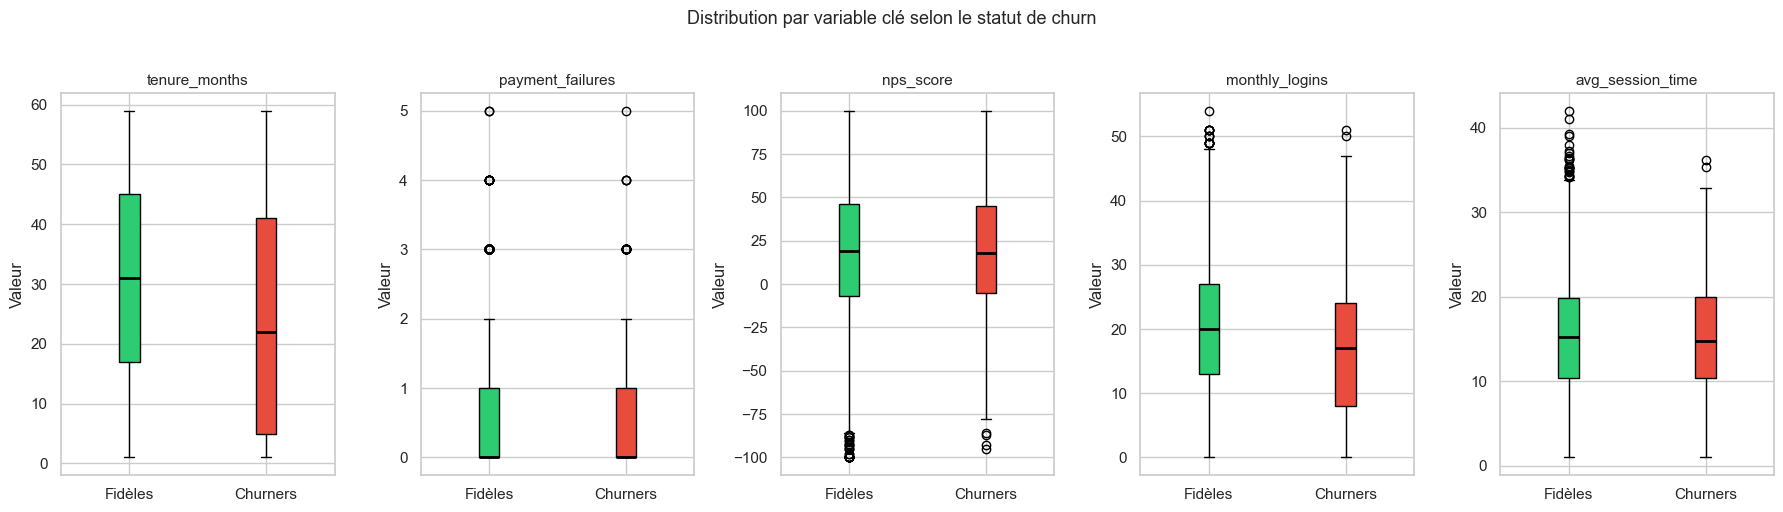

Médiane tenure_months — Fidèles : 31.0
Médiane tenure_months — Churners: 22.0
Médiane payment_failures — Fidèles : 0.0
Médiane payment_failures — Churners: 0.0
Médiane nps_score — Fidèles : 19.0
Médiane nps_score — Churners: 18.0


In [5]:
# Boxplots des variables les plus discriminantes selon le churn
key_vars = ['tenure_months', 'payment_failures', 'nps_score',
            'monthly_logins', 'avg_session_time']

fig, axes = plt.subplots(1, 5, figsize=(18, 5))
for ax, col in zip(axes, key_vars):
    groups = [df[df['churn'] == 0][col], df[df['churn'] == 1][col]]
    bp = ax.boxplot(groups, patch_artist=True,
                    medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][1].set_facecolor('#e74c3c')
    ax.set_xticklabels(['Fidèles', 'Churners'])
    ax.set_title(col, fontsize=11)
    ax.set_ylabel('Valeur')

fig.suptitle('Distribution par variable clé selon le statut de churn', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Lecture rapide
print('Médiane tenure_months — Fidèles :', df[df.churn==0]['tenure_months'].median())
print('Médiane tenure_months — Churners:', df[df.churn==1]['tenure_months'].median())
print('Médiane payment_failures — Fidèles :', df[df.churn==0]['payment_failures'].median())
print('Médiane payment_failures — Churners:', df[df.churn==1]['payment_failures'].median())
print('Médiane nps_score — Fidèles :', df[df.churn==0]['nps_score'].median())
print('Médiane nps_score — Churners:', df[df.churn==1]['nps_score'].median())


## 4. Matrice de corrélation

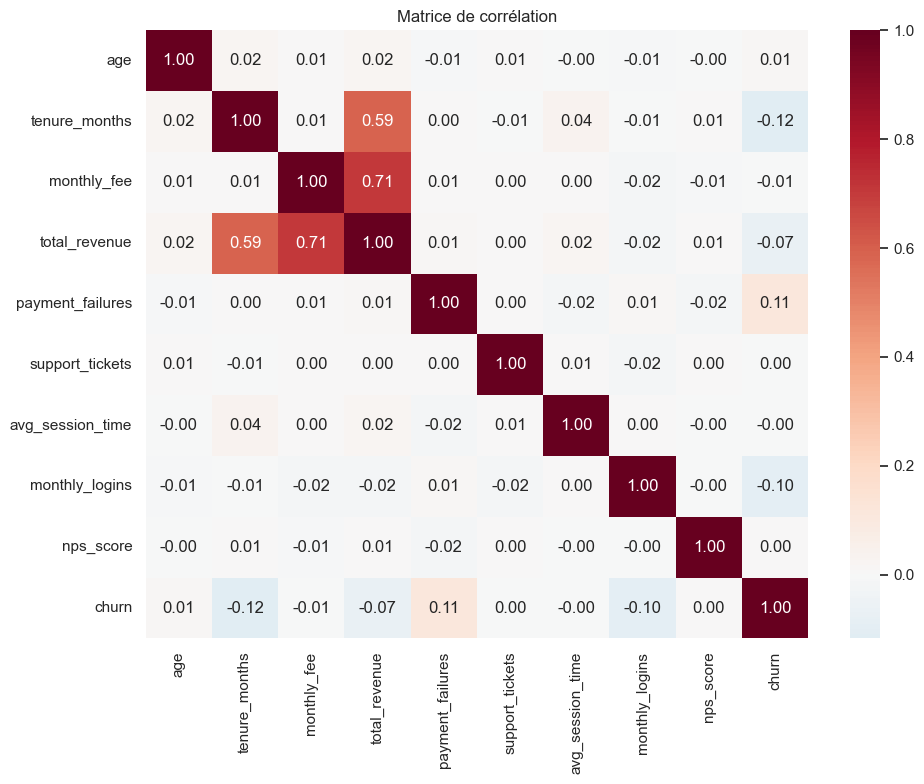


Corrélation avec churn :
churn               1.000000
payment_failures    0.112494
age                 0.010155
nps_score           0.002996
support_tickets     0.000317
avg_session_time   -0.004659
monthly_fee        -0.005048
total_revenue      -0.070120
monthly_logins     -0.098339
tenure_months      -0.117014
Name: churn, dtype: float64


In [6]:
corr = df[numeric_cols + ['churn']].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Matrice de corrélation')
plt.tight_layout()
plt.show()

print('\nCorrélation avec churn :')
print(corr['churn'].sort_values(ascending=False))

## 5. Variables catégorielles vs Churn

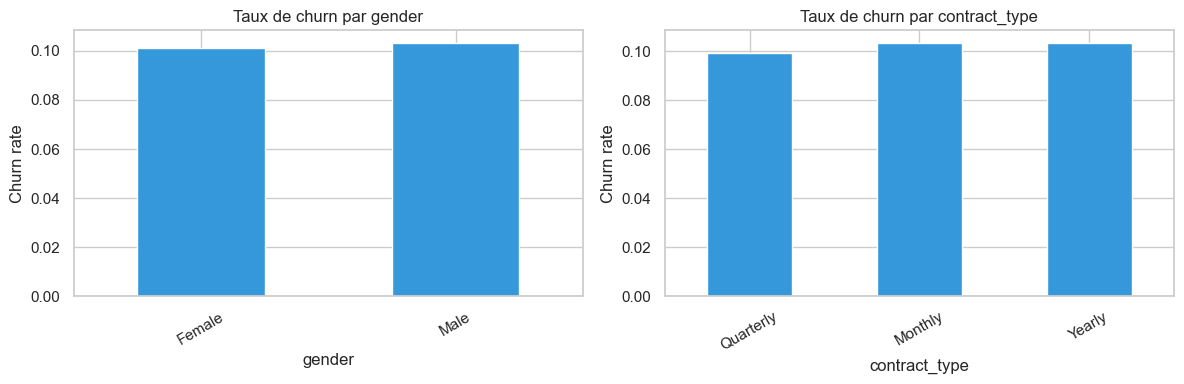

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col in zip(axes, ['gender', 'contract_type']):
    churn_rate = df.groupby(col)['churn'].mean().sort_values()
    churn_rate.plot.bar(ax=ax, color='#3498db')
    ax.set_title(f'Taux de churn par {col}')
    ax.set_ylabel('Churn rate')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30)

plt.tight_layout()
plt.show()

## 6. Analyse du revenu à risque

Revenu total à risque : 862,640 €
Clients à risque : 1021
Revenu moyen par churner : 845 €


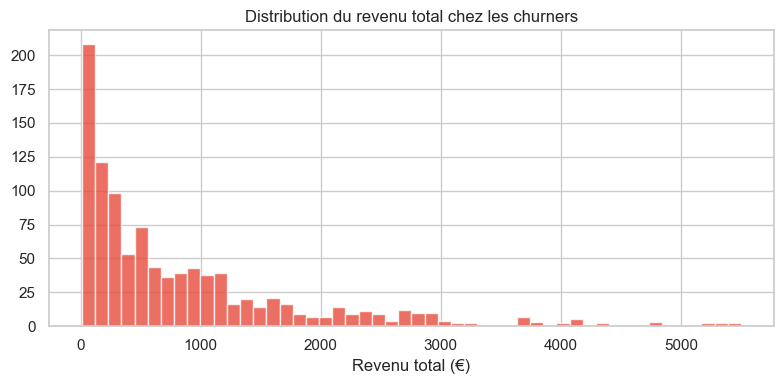

In [8]:
churners = df[df['churn'] == 1]
print(f'Revenu total à risque : {churners["total_revenue"].sum():,.0f} €')
print(f'Clients à risque : {len(churners)}')
print(f'Revenu moyen par churner : {churners["total_revenue"].mean():.0f} €')

plt.figure(figsize=(8, 4))
churners['total_revenue'].hist(bins=50, color='#e74c3c', alpha=0.8)
plt.title('Distribution du revenu total chez les churners')
plt.xlabel('Revenu total (€)')
plt.tight_layout()
plt.show()